In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score , recall_score, f1_score

# Example: load dataset
df = pd.read_csv("Soil_data.csv")

# Split features and target
X = df.drop("Fertility", axis=1)
y = df["Fertility"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# Convert to numpy
X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train.values
y_test_np = y_test.values

# Handle missing values
imputer = SimpleImputer(strategy="mean")
X_train_np = imputer.fit_transform(X_train_np)
X_test_np = imputer.transform(X_test_np)

# Remove infinite values
X_train_np[np.isinf(X_train_np)] = 0
X_test_np[np.isinf(X_test_np)] = 0

# Encode labels
le = LabelEncoder()
y_train_np = le.fit_transform(y_train_np)
y_test_np = le.transform(y_test_np)

In [10]:
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train_np, y_train_np)

y_pred_xgb = xgb.predict(X_test_np)

print("XGBoost Accuracy:", accuracy_score(y_test_np, y_pred_xgb))
print(classification_report(y_test_np, y_pred_xgb))

XGBoost Accuracy: 0.9924585218702866
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1811
           1       0.98      0.93      0.96       178

    accuracy                           0.99      1989
   macro avg       0.99      0.97      0.98      1989
weighted avg       0.99      0.99      0.99      1989



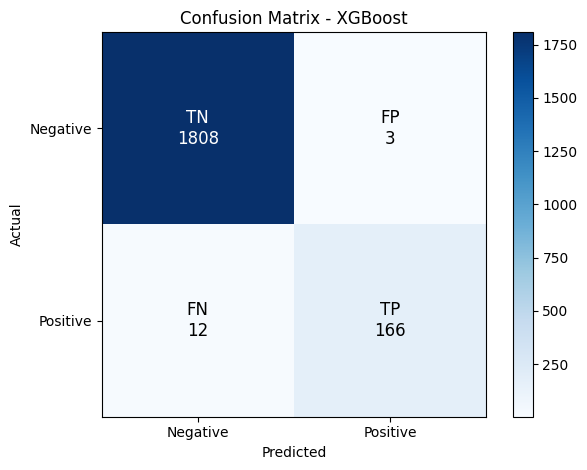

In [15]:
cm = confusion_matrix(y_test_np, y_pred_xgb)

plt.figure()

# Use better colormap
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix - XGBoost")
plt.colorbar()

classes = ['Negative', 'Positive']
plt.xticks(np.arange(2), classes)
plt.yticks(np.arange(2), classes)

# Extract values
TN, FP, FN, TP = cm.ravel()

labels = np.array([
    [f"TN\n{TN}", f"FP\n{FP}"],
    [f"FN\n{FN}", f"TP\n{TP}"]
])

# 🔥 Dynamic text color
threshold = cm.max() / 2

for i in range(2):
    for j in range(2):
        plt.text(
            j, i, labels[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=12
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

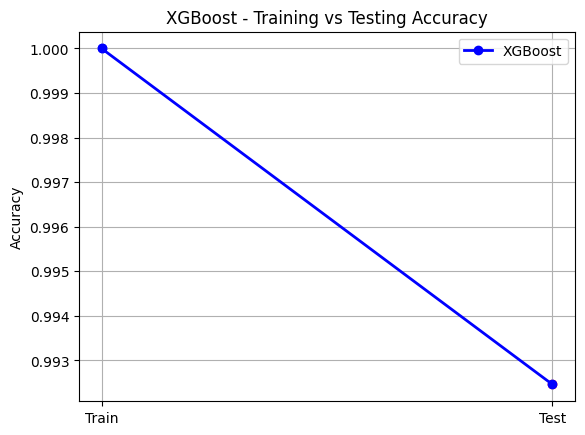

In [16]:
plt.figure()

train_acc_xgb = accuracy_score(y_train_np, xgb.predict(X_train_np))
test_acc_xgb = accuracy_score(y_test_np, y_pred_xgb)

plt.plot(['Train', 'Test'],
         [train_acc_xgb, test_acc_xgb],
         marker='o',
         linewidth=2,
         color='blue',
         label='XGBoost')

plt.scatter(['Train'], [train_acc_xgb], color='blue')
plt.scatter(['Test'], [test_acc_xgb], color='red')

plt.title("XGBoost - Training vs Testing Accuracy")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
lgbm = LGBMClassifier()
lgbm.fit(X_train_np, y_train_np)

y_pred_lgbm = lgbm.predict(X_test_np)

print("LightGBM Accuracy:", accuracy_score(y_test_np, y_pred_lgbm))
print(classification_report(y_test_np, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 717, number of negative: 7239
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001324 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2117
[LightGBM] [Info] Number of data points in the train set: 7956, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090121 -> initscore=-2.312163
[LightGBM] [Info] Start training from score -2.312163
LightGBM Accuracy: 0.9929612870789342
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1811
           1       0.97      0.95      0.96       178

    accuracy                           0.99      1989
   macro avg       0.98      0.97      0.98      1989
weighted avg       0.99      0.99      0.99      1989



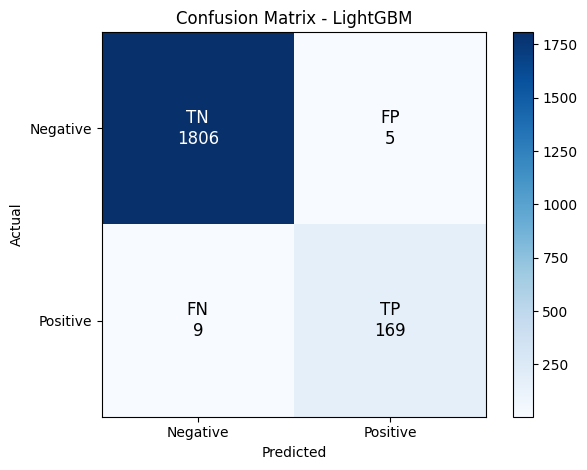

In [18]:
cm1 = confusion_matrix(y_test_np, y_pred_lgbm)

plt.figure()

# ✅ Use correct matrix + better colormap
plt.imshow(cm1, cmap="Blues")

plt.title("Confusion Matrix - LightGBM")
plt.colorbar()

classes = ['Negative', 'Positive']
plt.xticks(np.arange(2), classes)
plt.yticks(np.arange(2), classes)

# Extract values
TN, FP, FN, TP = cm1.ravel()

labels = np.array([
    [f"TN\n{TN}", f"FP\n{FP}"],
    [f"FN\n{FN}", f"TP\n{TP}"]
])

# ✅ Dynamic text color for visibility
threshold = cm1.max() / 2

for i in range(2):
    for j in range(2):
        plt.text(
            j, i, labels[i, j],
            ha="center", va="center",
            color="white" if cm1[i, j] > threshold else "black",
            fontsize=12
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

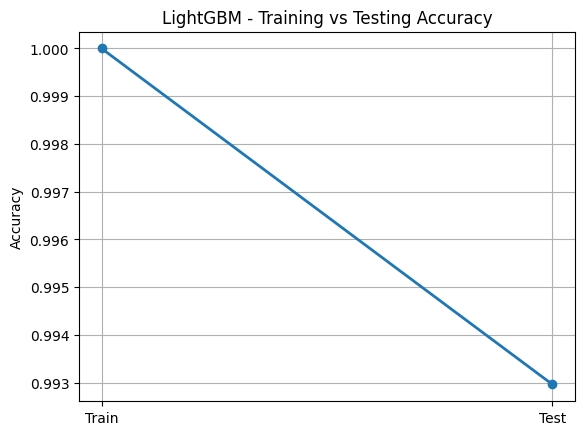

In [19]:
plt.figure()

train_acc_lgbm = accuracy_score(y_train_np, lgbm.predict(X_train_np))
test_acc_lgbm = accuracy_score(y_test_np, y_pred_lgbm)

plt.plot(['Train', 'Test'], [train_acc_lgbm, test_acc_lgbm], marker='o', linewidth=2)

plt.title("LightGBM - Training vs Testing Accuracy")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [20]:
cat = CatBoostClassifier(verbose=0)
cat.fit(X_train_np, y_train_np)

y_pred_cat = cat.predict(X_test_np)

print("CatBoost Accuracy:", accuracy_score(y_test_np, y_pred_cat))
print(classification_report(y_test_np, y_pred_cat))

CatBoost Accuracy: 0.9979889391654098
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1811
           1       1.00      0.98      0.99       178

    accuracy                           1.00      1989
   macro avg       1.00      0.99      0.99      1989
weighted avg       1.00      1.00      1.00      1989



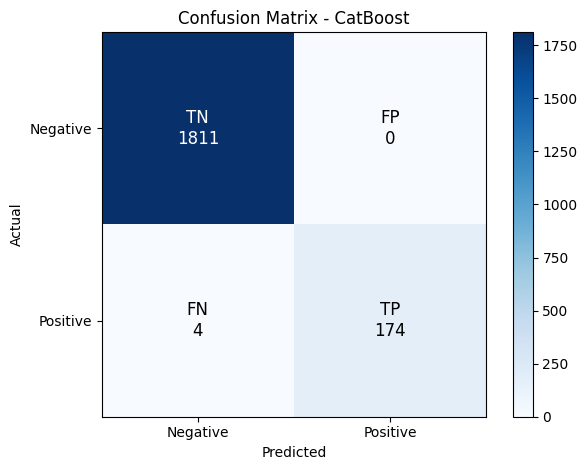

In [21]:
cm2 = confusion_matrix(y_test_np, y_pred_cat)

plt.figure()

# ✅ Use correct matrix + better background
plt.imshow(cm2, cmap="Blues")

plt.title("Confusion Matrix - CatBoost")
plt.colorbar()

classes = ['Negative', 'Positive']
plt.xticks(np.arange(2), classes)
plt.yticks(np.arange(2), classes)

# Extract values
TN, FP, FN, TP = cm2.ravel()

labels = np.array([
    [f"TN\n{TN}", f"FP\n{FP}"],
    [f"FN\n{FN}", f"TP\n{TP}"]
])

# ✅ Dynamic text color for visibility
threshold = cm2.max() / 2

for i in range(2):
    for j in range(2):
        plt.text(
            j, i, labels[i, j],
            ha="center", va="center",
            color="white" if cm2[i, j] > threshold else "black",
            fontsize=12
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [22]:
tabnet = TabNetClassifier(verbose=0)

tabnet.fit(
    X_train_np, y_train_np,
    eval_set=[(X_train_np, y_train_np), (X_test_np, y_test_np)],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=10
)

y_pred_tab = tabnet.predict(X_test_np)

print("TabNet Accuracy:", accuracy_score(y_test_np, y_pred_tab))
print(classification_report(y_test_np, y_pred_tab))


Early stopping occurred at epoch 10 with best_epoch = 0 and best_val_1_accuracy = 0.91051


C:\Users\ok\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
C:\Users\ok\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\_utils\collate.py:285: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  return collate([torch.as_tensor(b) for b in batch], collate_fn_map=collate_fn_map)


TabNet Accuracy: 0.910507792860734
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1811
           1       0.00      0.00      0.00       178

    accuracy                           0.91      1989
   macro avg       0.46      0.50      0.48      1989
weighted avg       0.83      0.91      0.87      1989



C:\Users\ok\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ok\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ok\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

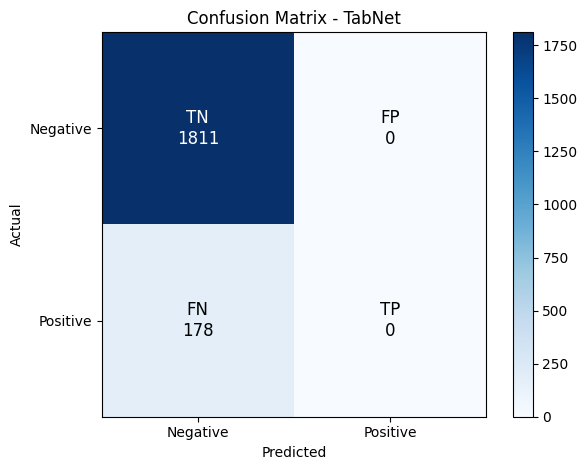

In [23]:
cm3 = confusion_matrix(y_test_np, y_pred_tab)

plt.figure()

# ✅ Use correct matrix + better color
plt.imshow(cm3, cmap="Blues")

plt.title("Confusion Matrix - TabNet")
plt.colorbar()

classes = ['Negative', 'Positive']
plt.xticks(np.arange(2), classes)
plt.yticks(np.arange(2), classes)

# Extract values
TN, FP, FN, TP = cm3.ravel()

labels = np.array([
    [f"TN\n{TN}", f"FP\n{FP}"],
    [f"FN\n{FN}", f"TP\n{TP}"]
])

# ✅ Dynamic text color
threshold = cm3.max() / 2

for i in range(2):
    for j in range(2):
        plt.text(
            j, i, labels[i, j],
            ha="center", va="center",
            color="white" if cm3[i, j] > threshold else "black",
            fontsize=12
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

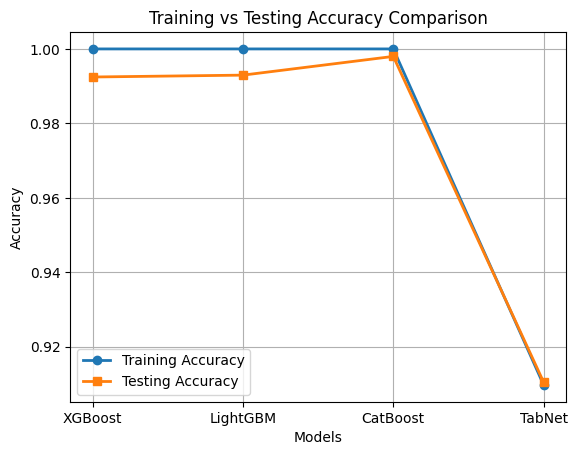

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

models = ['XGBoost', 'LightGBM', 'CatBoost', 'TabNet']

train_acc = [
    accuracy_score(y_train_np, xgb.predict(X_train_np)),
    accuracy_score(y_train_np, lgbm.predict(X_train_np)),
    accuracy_score(y_train_np, cat.predict(X_train_np)),
    accuracy_score(y_train_np, tabnet.predict(X_train_np))
]

test_acc = [
    accuracy_score(y_test_np, y_pred_xgb),
    accuracy_score(y_test_np, y_pred_lgbm),
    accuracy_score(y_test_np, y_pred_cat),
    accuracy_score(y_test_np, y_pred_tab)
]

x = np.arange(len(models))

plt.figure()

# Plot training accuracy
plt.plot(x, train_acc, marker='o', linewidth=2, label='Training Accuracy')

# Plot testing accuracy
plt.plot(x, test_acc, marker='s', linewidth=2, label='Testing Accuracy')

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Training vs Testing Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.show()

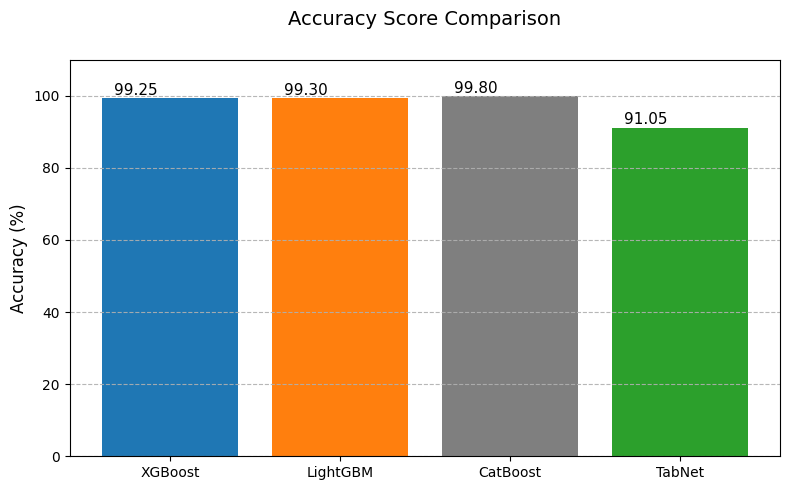

In [25]:
import matplotlib.pyplot as plt
import numpy as np

acc_xgb = accuracy_score(y_test_np, y_pred_xgb) * 100
acc_lgbm = accuracy_score(y_test_np, y_pred_lgbm) * 100
acc_cat = accuracy_score(y_test_np, y_pred_cat) * 100
acc_tab = accuracy_score(y_test_np, y_pred_tab) * 100

models = ['XGBoost', 'LightGBM', 'CatBoost', 'TabNet']
accuracies = [acc_xgb, acc_lgbm, acc_cat, acc_tab]

colors = ['#1f77b4', '#ff7f0e', '#7f7f7f', '#2ca02c']

plt.figure(figsize=(8,5))   # Taller figure

bars = plt.bar(models, accuracies, color=colors)

plt.ylim(0, 110)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Accuracy Score Comparison", fontsize=14, pad=25)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/4,
             height + 1,
             f'{height:.2f}',
             ha='center',
             fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.9)

plt.tight_layout()
plt.show()

In [28]:
def get_metrics(y_true, y_pred):
    return {
        "Precision": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "Recall": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "F1": f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

print("XGBoost:", get_metrics(y_test_np, y_pred_xgb))
print("LightGBM:", get_metrics(y_test_np, y_pred_lgbm))
print("CatBoost:", get_metrics(y_test_np, y_pred_cat))
print("TabNet:", get_metrics(y_test_np, y_pred_tab))

XGBoost: {'Precision': 0.9878275570583264, 'Recall': 0.9654638631583519, 'F1': 0.9763206204656191}
LightGBM: {'Precision': 0.9831528450650708, 'Recall': 0.9733386483350809, 'F1': 0.9781831344331344}
CatBoost: {'Precision': 0.9988980716253444, 'Recall': 0.9887640449438202, 'F1': 0.9937666098380384}
TabNet: {'Precision': 0.455253896430367, 'Recall': 0.5, 'F1': 0.47657894736842105}


C:\Users\ok\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


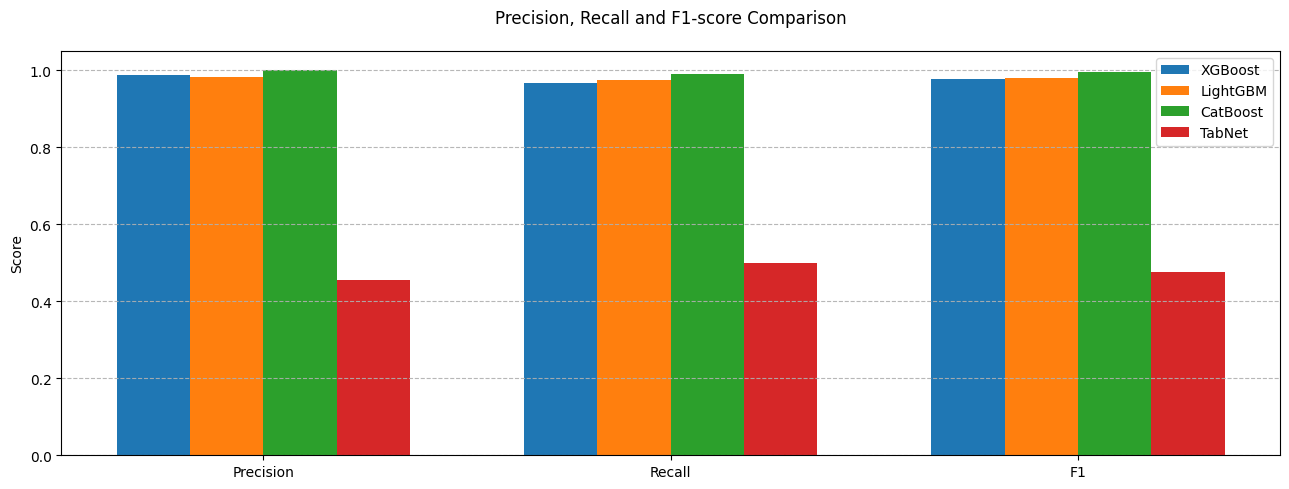

In [30]:
import numpy as np
import matplotlib.pyplot as plt
prec_xgb = precision_score(y_test, y_pred_xgb, average='macro')
rec_xgb  = recall_score(y_test, y_pred_xgb, average='macro')
f1_xgb   = f1_score(y_test, y_pred_xgb, average='macro')
prec_lgbm = precision_score(y_test, y_pred_lgbm, average='macro')
rec_lgbm  = recall_score(y_test, y_pred_lgbm, average='macro')
f1_lgbm   = f1_score(y_test, y_pred_lgbm, average='macro')
prec_cat = precision_score(y_test, y_pred_cat, average='macro')
rec_cat  = recall_score(y_test, y_pred_cat, average='macro')
f1_cat   = f1_score(y_test, y_pred_cat, average='macro')
prec_tab = precision_score(y_test, y_pred_tab, average='macro')
rec_tab  = recall_score(y_test, y_pred_tab, average='macro')
f1_tab   = f1_score(y_test, y_pred_tab, average='macro')
metrics = ['Precision', 'Recall', 'F1']

x = np.arange(len(metrics))
width = 0.18

plt.figure(figsize=(13,5))

plt.bar(x - 1.5*width, [prec_xgb, rec_xgb, f1_xgb], width, label='XGBoost')
plt.bar(x - 0.5*width, [prec_lgbm, rec_lgbm, f1_lgbm], width, label='LightGBM')
plt.bar(x + 0.5*width, [prec_cat, rec_cat, f1_cat], width, label='CatBoost')
plt.bar(x + 1.5*width, [prec_tab, rec_tab, f1_tab], width, label='TabNet')

plt.xticks(x, metrics) 
plt.ylim(0, 1.05)

plt.ylabel("Score")
plt.title("Precision, Recall and F1-score Comparison", pad=20)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.9)

plt.tight_layout()
plt.show()

In [31]:
cat.save_model("catboost_model.cbm")